In [2]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis

In [3]:
#Function Definitions
def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

def index_of_just_smaller(arr, value):
    arr = np.asarray(arr)
    mask = arr < value
    if not np.any(mask):
        return None  # No smaller value exists
    return np.argmax(np.where(mask, arr, -np.inf))

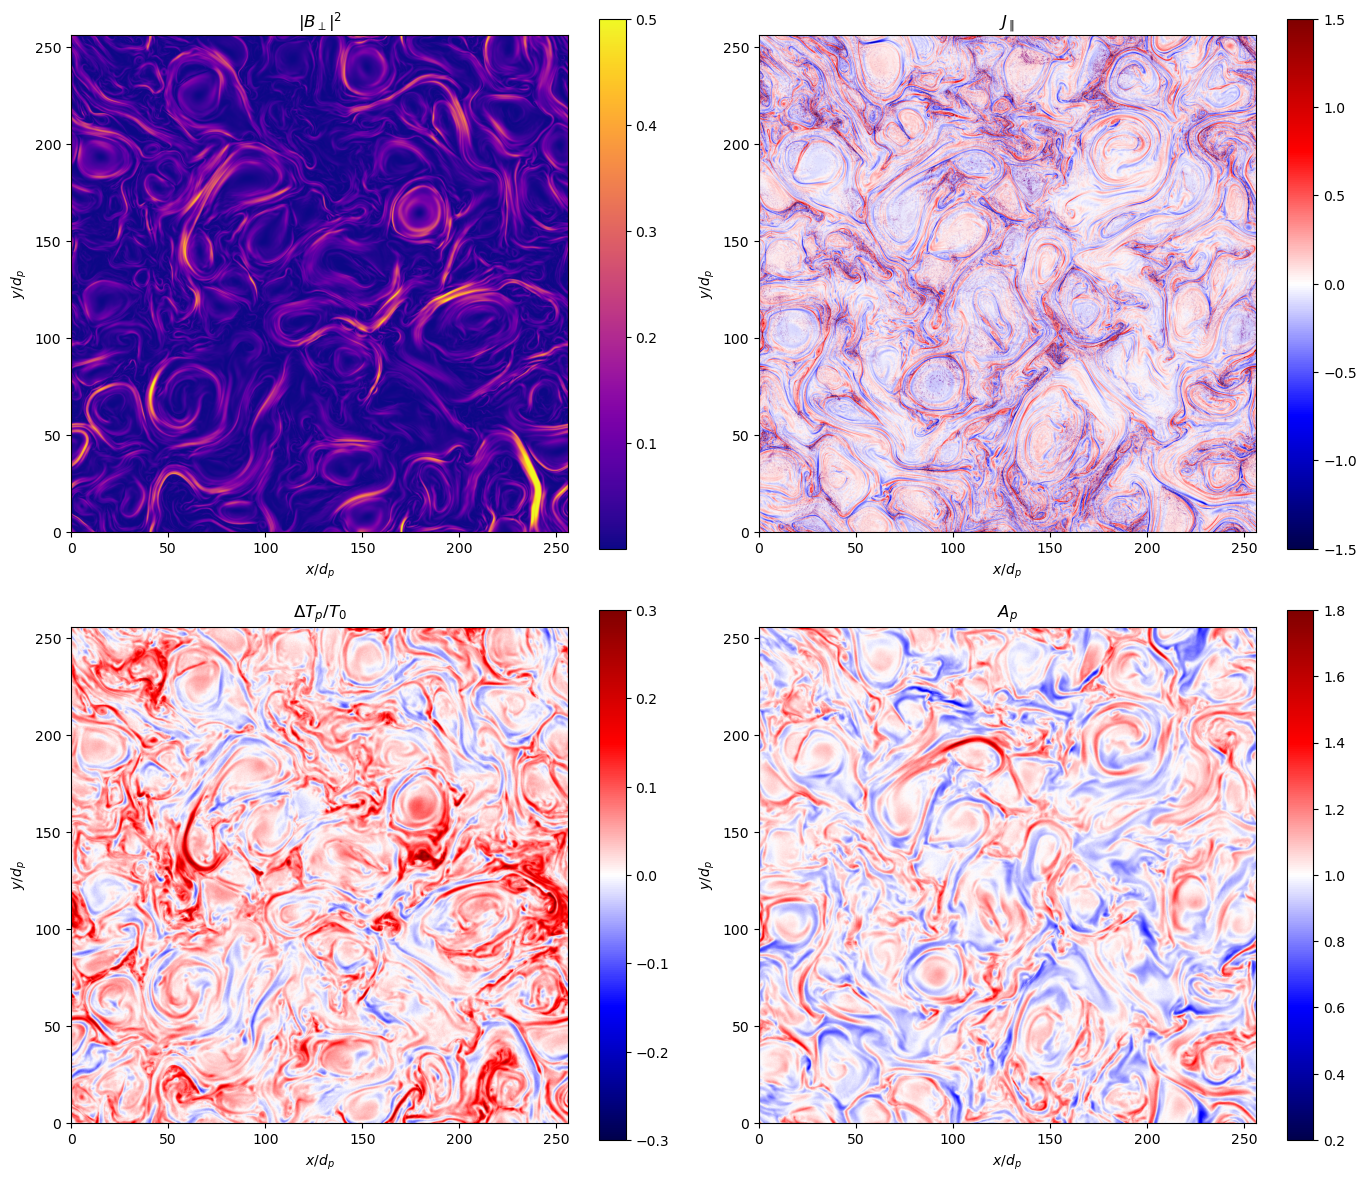

In [6]:
# File paths
path = '/DATA/DEVESH/ApJ2015/'
files = {
    'Bx': path + 'Bx_ApJ_t200.h5',
    'By': path + 'By_ApJ_t200.h5',
    'Ux': path + 'Ux1_ApJ_t200.h5',
    'Uy': path + 'Uy1_ApJ_t200.h5',
    'Dn': path + 'Dn1_ApJ_t200.h5',
    'Ppar': path + 'Ppar1_ApJ_t200.h5',
    'Pper': path + 'Pper1_ApJ_t200.h5'
}

# Load fields
with h5py.File(files['Bx'], 'r') as fBx, h5py.File(files['By'], 'r') as fBy:
    Bx = fBx['DS1'][:]
    By = fBy['DS1'][:]
    Bx_T = Bx.T
    By_T = By.T
    B_perp2 = Bx**2 + By**2

with h5py.File(files['Ux'], 'r') as fUx, h5py.File(files['Uy'], 'r') as fUy, h5py.File(files['Dn'], 'r') as fDn:
    Ux = fUx['DS1'][:]
    Uy = fUy['DS1'][:]
    Dn = fDn['DS1'][:]
    Ux_T = Ux.T / Dn.T
    Uy_T = Uy.T / Dn.T

# J_parallel from FFT
J_par = partial_x_fft(By_T, 0.125) - partial_y_fft(Bx_T, 0.125)

# ΔT_p / T_0
T_naught = 0.25
with h5py.File(files['Ppar'], 'r') as fPpar, h5py.File(files['Pper'], 'r') as fPper:
    Ppar = fPpar['DS1'][:]
    Pper = fPper['DS1'][:]
    Tpar = Ppar / Dn
    Tper = Pper / Dn
    Ttot = (2 * Tper + Tpar) / 3
    delta_T_by_T0 = (Ttot - T_naught) / T_naught

# Temperature Anisotropy A_p = T_perp / T_par
Tper_T = Pper.T / Dn.T
Tpar_T = Ppar.T / Dn.T
Aniso = Tper_T / Tpar_T

# Set up 2x2 subplot grid (ignore 1 unused panel)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
extent = [0, 256, 0, 256]

# Plot 1: |B_perp|^2
im0 = axes[0, 0].imshow(B_perp2, cmap='plasma', vmax=0.5, extent=extent)
axes[0, 0].set_title(r'$|B_\perp|^2$')
axes[0, 0].set_xlabel(r'$x/d_{p}$')
axes[0, 0].set_ylabel(r'$y/d_{p}$')
fig.colorbar(im0, ax=axes[0, 0])

# Plot 2: J_parallel
im1 = axes[0, 1].imshow(J_par, cmap='seismic', vmin=-1.5, vmax=1.5, extent=extent)
axes[0, 1].set_title(r'$J_\parallel$')
axes[0, 1].set_xlabel(r'$x/d_{p}$')
axes[0, 1].set_ylabel(r'$y/d_{p}$')
fig.colorbar(im1, ax=axes[0, 1])

# Plot 3: ΔT_p/T_0
im2 = axes[1, 0].imshow(delta_T_by_T0, cmap='seismic', vmin=-0.3, vmax=0.3, extent=extent)
axes[1, 0].set_title(r'$\Delta T_{p}/T_{0}$')
axes[1, 0].set_xlabel(r'$x/d_{p}$')
axes[1, 0].set_ylabel(r'$y/d_{p}$')
fig.colorbar(im2, ax=axes[1, 0])

# Plot 4: A_p
im3 = axes[1, 1].imshow(Aniso, cmap='seismic', vmin=0.2, vmax=1.8, extent=extent)
axes[1, 1].set_title(r'$A_{p}$')
axes[1, 1].set_xlabel(r'$x/d_{p}$')
axes[1, 1].set_ylabel(r'$y/d_{p}$')
fig.colorbar(im3, ax=axes[1, 1])

# Adjust layout
plt.tight_layout()
plt.savefig("visuals.png")
plt.show()